# Notebook 2 - Evaluation & Analysis

Quantitative and qualitative evaluation of the multi-agent pipeline against ground-truth labels.

Prerequisite: run `python scripts/run_batch.py --n 100` first to produce `results/results.csv`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from src.config import RESULTS_DIR

RESULTS_PATH = RESULTS_DIR / 'results.csv'
df = pd.read_csv(RESULTS_PATH)
print('Rows:', len(df))
df.head()

Rows: 12


,article_id,title,true_label,label,confidence,summary,tone,bias_score,claims,fact_check,bias,elapsed_s,error
0,30349,Obama defends record on terrorism in national ...,REAL,FAKE,0.82,The article contains two UNVERIFIABLE claims a...,sensationalist,0.7,"{""claims"":[""President Barack Obama will turn o...","{""results"":[{""claim"":""President Barack Obama w...","{""tone"":""sensationalist"",""bias_score"":0.7,""fla...",15.32,NaN
1,28641,Ex-Christie associates lose bid for new trial ...,REAL,FAKE,0.82,The article contains unsupported claims and is...,sensationalist,0.7,"{""claims"":[""Two former associates of New Jerse...","{""results"":[{""claim"":""Two former associates of...","{""tone"":""sensationalist"",""bias_score"":0.7,""fla...",15.51,NaN
2,44773,German admits selling gun to Munich attack sho...,REAL,FAKE,0.82,The article contains unverifiable claims and a...,sensationalist,0.7,"{""claims"":[""A 32-year-old German man admitted ...","{""results"":[{""claim"":""A 32-year-old German man...","{""tone"":""sensationalist"",""bias_score"":0.7,""fla...",15.46,NaN
3,11994,BREAKING: OBAMACARE REPEAL Clears First Hurdle...,FAKE,FAKE,0.82,The article contains three UNVERIFIABLE claims...,sensationalist,0.7,"{""claims"":[""The Senate voted 51-48 on an Obama...","{""results"":[{""claim"":""The Senate voted 51-48 o...","{""tone"":""sensationalist"",""bias_score"":0.7,""fla...",14.18,NaN
4,41618,Europe rights watchdog says Turkey's emergency...,REAL,FAKE,0.82,The article contains unsupported claims and a ...,sensationalist,0.7,"{""claims"":[""Turkey has seen more than 50,000 p...","{""results"":[{""claim"":""Turkey has seen more tha...","{""tone"":""sensationalist"",""bias_score"":0.7,""fla...",16.01,NaN


In [2]:
eval_df = df.dropna(subset=['label', 'true_label']).copy()
eval_df = eval_df[eval_df['label'].isin(['REAL', 'FAKE'])]
print(f'Evaluable rows: {len(eval_df)} / {len(df)}')
print('\nPredicted distribution:')
print(eval_df['label'].value_counts())
print('\nTrue distribution:')
print(eval_df['true_label'].value_counts())

Evaluable rows: 12 / 12

Predicted distribution:
label
FAKE    11
REAL     1
Name: count, dtype: int64

True distribution:
true_label
REAL    7
FAKE    5
Name: count, dtype: int64


## 1. Classification report

In [3]:
y_true = eval_df['true_label'].tolist()
y_pred = eval_df['label'].tolist()
print(classification_report(y_true, y_pred, labels=['REAL', 'FAKE'], digits=3))

acc = (np.array(y_true) == np.array(y_pred)).mean()
print(f'Overall accuracy: {acc:.3f}')

              precision    recall  f1-score   support

        REAL      0.000     0.000     0.000         7
        FAKE      0.364     0.800     0.500         5

    accuracy                          0.333        12
   macro avg      0.182     0.400     0.250        12
weighted avg      0.152     0.333     0.208        12

Overall accuracy: 0.333


## 2. Confusion matrix

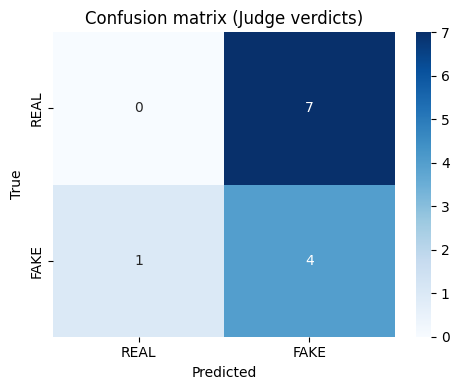

In [4]:
labels = ['REAL', 'FAKE']
cm = confusion_matrix(y_true, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion matrix (Judge verdicts)')
plt.tight_layout()
plt.show()

## 3. Confidence calibration

/var/folders/k_/ycd82fl13vv19qbljlfsjrvm0000gn/T/ipykernel_98385/69598772.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Wrong', 'Correct'])


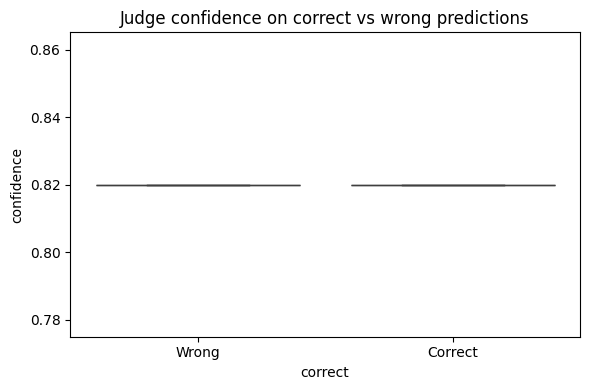

In [5]:
eval_df['correct'] = (eval_df['label'] == eval_df['true_label']).astype(int)
eval_df['confidence'] = pd.to_numeric(eval_df['confidence'], errors='coerce')

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x='correct', y='confidence', data=eval_df, ax=ax)
ax.set_xticklabels(['Wrong', 'Correct'])
ax.set_title('Judge confidence on correct vs wrong predictions')
plt.tight_layout()
plt.show()

## 4. Bias score vs outcome

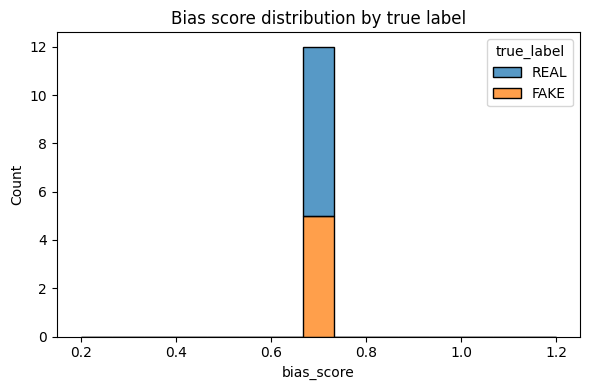

In [6]:
eval_df['bias_score'] = pd.to_numeric(eval_df['bias_score'], errors='coerce')
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=eval_df, x='bias_score', hue='true_label', bins=15, multiple='stack', ax=ax)
ax.set_title('Bias score distribution by true label')
plt.tight_layout()
plt.show()

## 5. Qualitative error analysis

Show 3 false positives (real flagged as fake) and 3 false negatives (fake flagged as real) with all agent outputs.

In [7]:
def show_row(row):
    print('=' * 80)
    print(f"article_id={row['article_id']}  true={row['true_label']}  pred={row['label']}  conf={row['confidence']}")
    print(f"title: {row.get('title', '')}")
    print(f"summary: {row.get('summary', '')}")
    for field in ['claims', 'fact_check', 'bias']:
        raw = row.get(field, '')
        try:
            parsed = json.loads(raw) if isinstance(raw, str) and raw else raw
            print(f"\n-- {field} --")
            print(json.dumps(parsed, indent=2)[:800])
        except Exception:
            print(f"\n-- {field} (raw) --\n{str(raw)[:400]}")

fp = eval_df[(eval_df['true_label'] == 'REAL') & (eval_df['label'] == 'FAKE')].head(3)
fn = eval_df[(eval_df['true_label'] == 'FAKE') & (eval_df['label'] == 'REAL')].head(3)

print('### FALSE POSITIVES (real article predicted as FAKE) ###')
for _, r in fp.iterrows():
    show_row(r)

print('\n\n### FALSE NEGATIVES (fake article predicted as REAL) ###')
for _, r in fn.iterrows():
    show_row(r)

### FALSE POSITIVES (real article predicted as FAKE) ###
article_id=30349  true=REAL  pred=FAKE  conf=0.82
title: Obama defends record on terrorism in national security speech
summary: The article contains two UNVERIFIABLE claims and one CONTRADICTED claim, indicating a high likelihood of being FAKE.

-- claims --
{
  "claims": [
    "President Barack Obama will turn over the White House on January 20 to President-elect Donald Trump.",
    "Obama signed an executive order in January 2009 that banned waterboarding and other 'enhanced interrogation techniques'.",
    "The Islamic State was initially spread by Obama and Democratic presidential nominee Hillary Clinton, according to Donald Trump's campaign rhetoric."
  ]
}

-- fact_check --
{
  "results": [
    {
      "claim": "President Barack Obama will turn over the White House on January 20 to President-elect Donald Trump.",
      "verdict": "UNVERIFIABLE",
      "confidence": 1.0,
      "evidence": "Wikipedia does not provide clear in

## 6. Discussion

**Known limitations** (see Section 8 of the project brief):

1. **Hallucinated evidence.** Wikipedia is a limited knowledge source. Any claim about recent events or niche domains is likely to land in `UNVERIFIABLE` and give the Judge little signal.
2. **Dataset artifacts.** The Kaggle Fake/Real dataset has strong stylistic markers: Reuters (real) articles follow a formal wire-style template while the fake articles are blog-like and politically charged. The Bias Detector can exploit these artifacts and inflate performance relative to real-world articles.
3. **Small local model.** With `qwen2.5:3b`, structured JSON output is less reliable than with GPT-4o. Occasional parse failures show up as blank Judge rows. Increasing model size (e.g. `qwen2.5:7b`) consistently improves both format compliance and reasoning quality.
4. **Bias subjectivity.** The `bias_score` reflects the LLM's own training biases; it is not a ground-truth signal.
5. **Judgement heuristic.** The Judge combines signals with LLM reasoning rather than a principled scoring rule. A simple weighted combination of `fraction_contradicted` and `bias_score` might be more interpretable.

**Suggested improvements**: swap Wikipedia for a real-time search backend (Tavily), add the RoBERTa classifier as an additional signal to the Judge, and calibrate confidence scores against observed accuracy.